<a href="https://colab.research.google.com/github/winston-k/Wi20260413/blob/main/py2112h_lrg1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Example, HDB Prices Estimation ...


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seabornInstance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline
from google.colab import drive

drive.mount('/content/drive')

# Load the dataset
file_path = "/content/drive/My Drive/Emeritus/Wi20260415/Module2-7/resale-sample.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
dataset = pd.read_csv(file_path)

In [30]:
dataset.shape

(2000, 11)

In [31]:
dataset.describe()

,Unnamed: 0,floor_area_sqm,lease_commence_date,resale_price
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,50160.695000,97.389250,1990.445500,453921.532940
std,28817.097081,24.387528,10.581352,129727.518779
min,24.000000,34.000000,1967.000000,210000.000000
25%,24862.750000,76.000000,1983.000000,360000.000000
50%,49678.500000,97.000000,1988.000000,430000.000000
75%,75137.750000,111.000000,1999.250000,515250.000000
max,100324.000000,179.000000,2013.000000,991000.000000


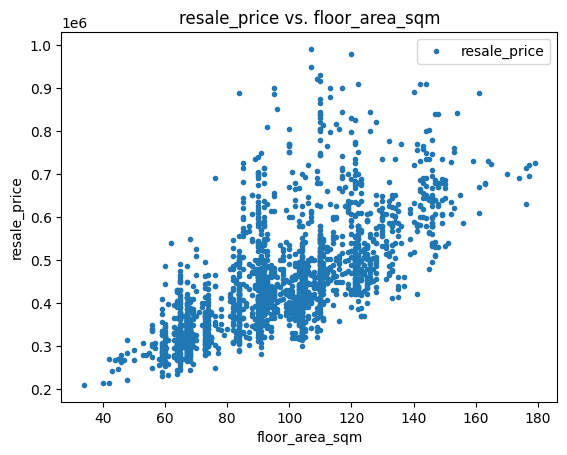

In [32]:
dataset.plot(x='floor_area_sqm', y='resale_price', style='.')
plt.title('resale_price vs. floor_area_sqm')
plt.ylabel('resale_price')
plt.xlabel('floor_area_sqm')
plt.show()

distplot : 
displot : 


/tmp/ipykernel_2948/58142439.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  seabornInstance.distplot(dataset['floor_area_sqm'])


histplot : 


<Axes: xlabel='floor_area_sqm', ylabel='Density'>

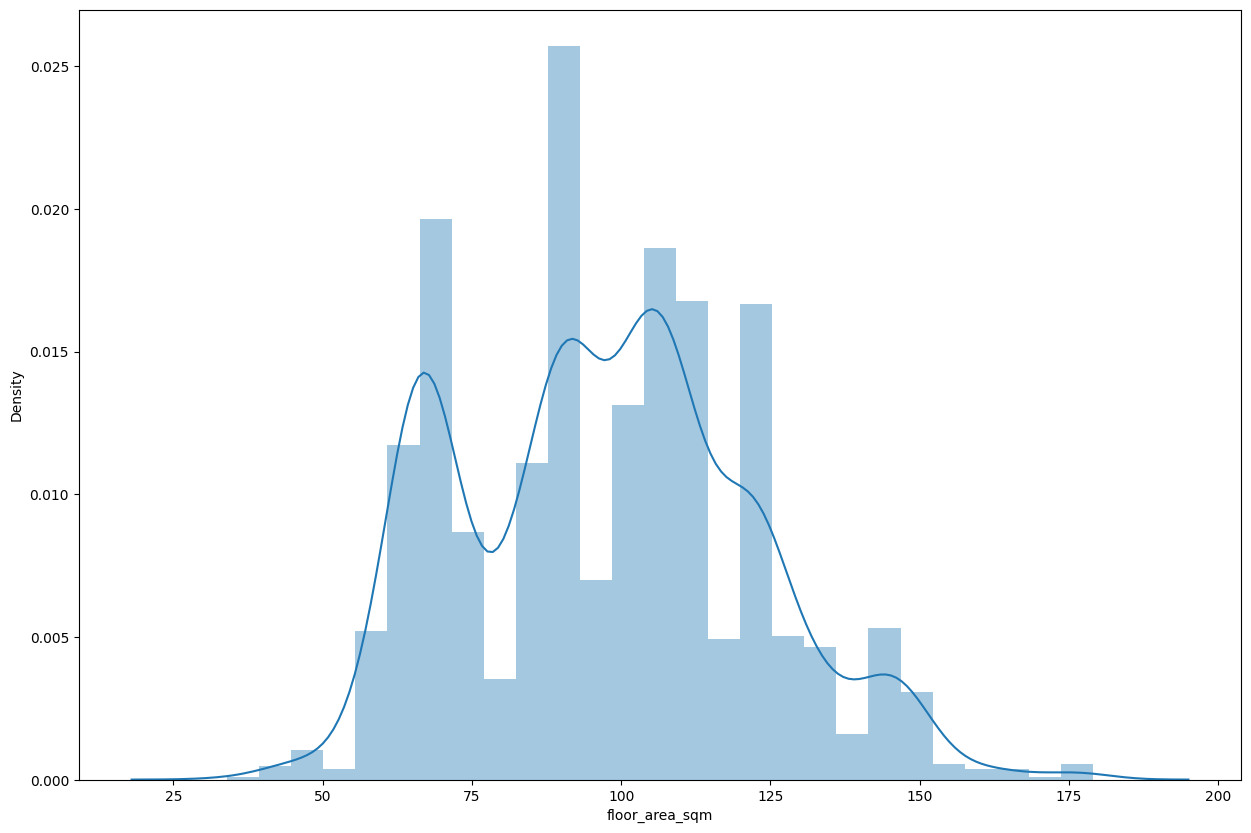

<Figure size 1500x1000 with 0 Axes>

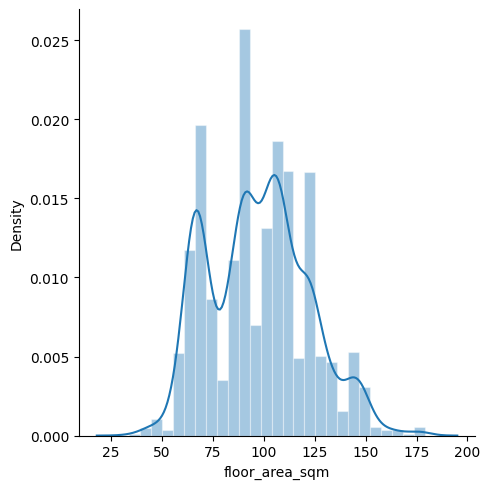

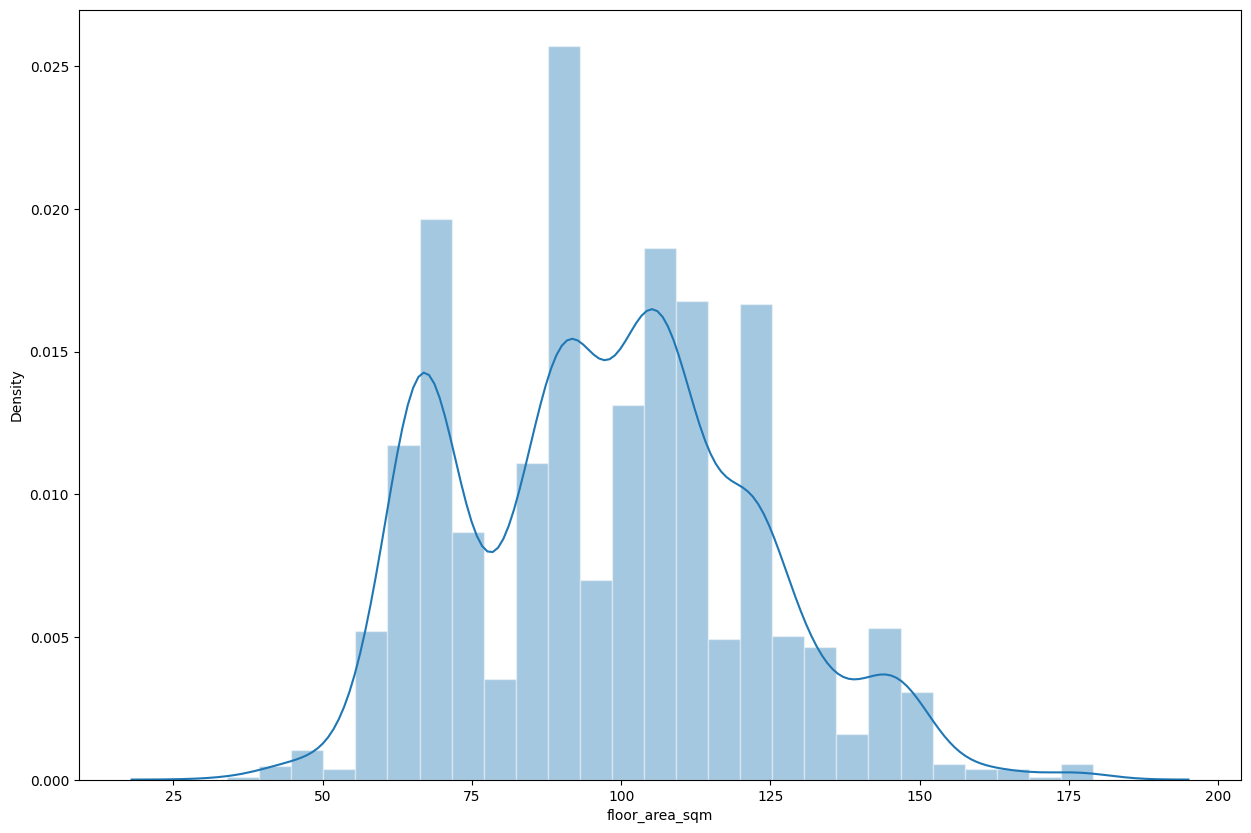

In [33]:

print("distplot : ")
plt.figure(figsize=(15,10))
plt.tight_layout()

seabornInstance.distplot(dataset['floor_area_sqm'])


print("displot : ")
plt.figure(figsize=(15,10))
plt.tight_layout()

seabornInstance.displot(dataset['floor_area_sqm'], kde=True,
                        stat="density", kde_kws=dict(cut=3),
                        alpha=.4, edgecolor=(1, 1, 1, .4),)


print("histplot : ")
plt.figure(figsize=(15,10))
plt.tight_layout()

seabornInstance.histplot(dataset['floor_area_sqm'], kde=True,
                         stat="density", kde_kws=dict(cut=3),
                         alpha=.4, edgecolor=(1, 1, 1, .4),)

In [34]:
X = dataset['floor_area_sqm'].values.reshape(-1,1)
y = dataset['resale_price'].values.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
regressor = LinearRegression()
regressor.fit(X_train, y_train) #training the algorithm
#To retrieve the intercept:
print(regressor.intercept_)
#For retrieving the slope:
print(regressor.coef_)

[99200.12048549]
[[3633.15226223]]


In [35]:
y_pred = regressor.predict(X_test)

In [36]:
df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
df

,Actual,Predicted
0,530000.0,553344.153264
1,280000.0,331721.865268
2,350000.0,397118.605988
3,430000.0,335355.017531
4,363000.0,364420.235628
...,...,...
395,390000.0,477047.955758
396,472000.0,538811.544216
397,440000.0,498846.869331
398,425000.0,542444.696478


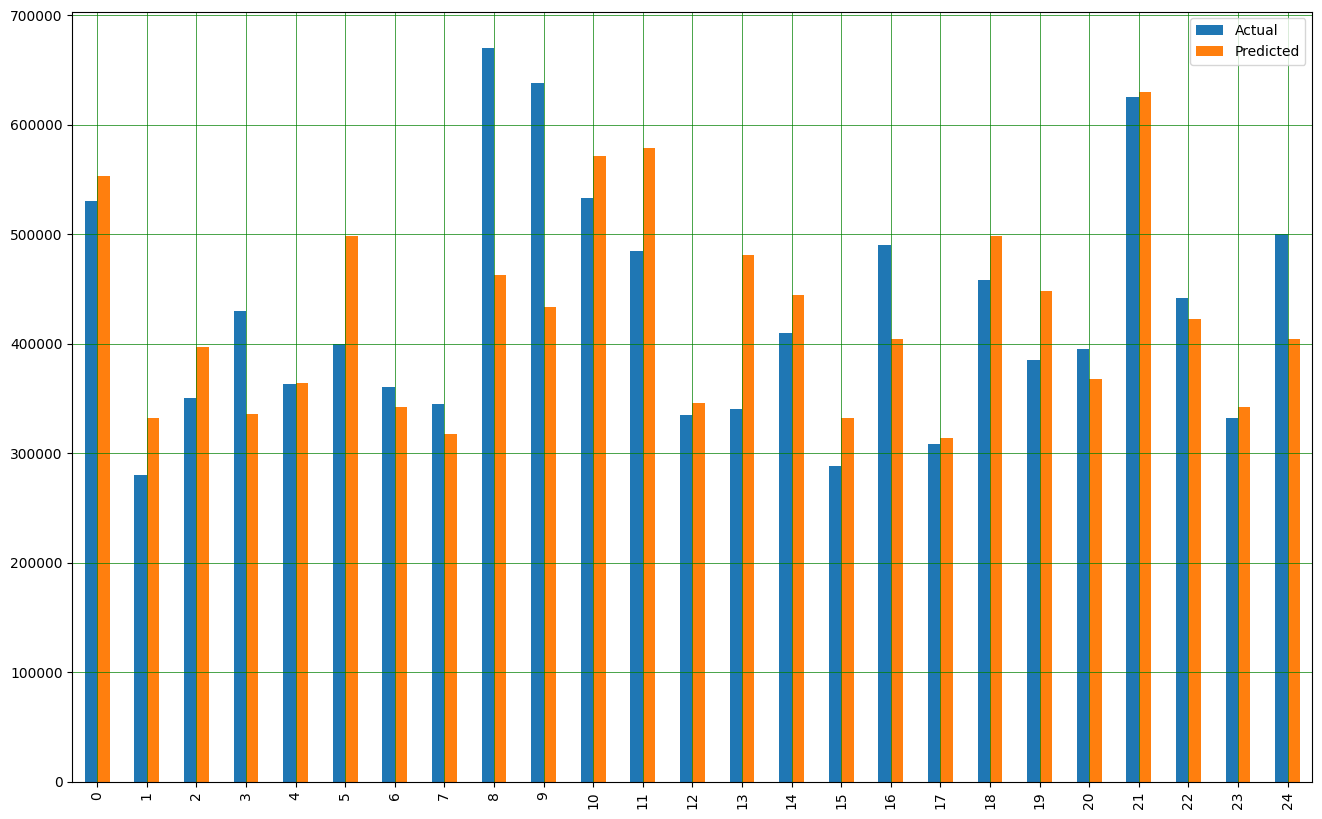

In [37]:
df1 = df.head(25)
df1.plot(kind='bar',figsize=(16,10))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

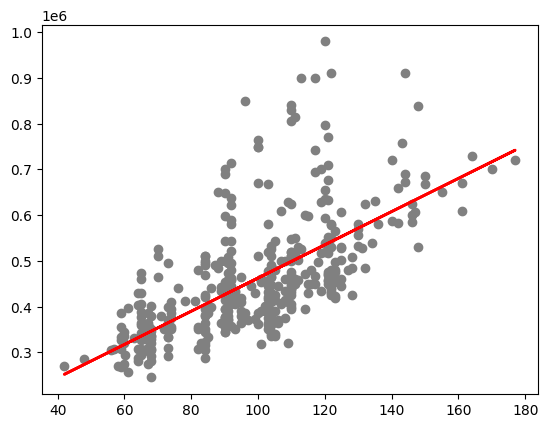

In [38]:
plt.scatter(X_test, y_test,  color='gray')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.show()

In [39]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 70357.60138898242
Mean Squared Error: 9993072292.213175
Root Mean Squared Error: 99965.35545984506


In [40]:
area = 125
aa= np.array([area])
aa = np.reshape(aa,[1,1])
price = regressor.predict(aa)
print('\narea=',area,'\tprice=',price)


area= 125 	price= [[553344.15326444]]


In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. Use celebs2.csv dataset
# Ensure the drive is mounted if not already (it was in previous cells, but good to ensure context)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

celebs_file_path = "/content/drive/My Drive/Emeritus/Wi20260415/Module2-7/celebs2.csv"
celebs_dataset = pd.read_csv(celebs_file_path)

# 3. This way height = F(weight)
# 4. Try linear regression, just keep the 1st and 2nd variables, height and weight
# Assuming 'height' is the first variable and 'weight' is the second based on common CSV structure
# Let's inspect the columns to be sure. If not specified, I'll assume they are 'height' and 'weight'
# For now, I will use the first two columns, assuming 'height' and 'weight' are the first two

# Check dataset head to confirm column names if available, otherwise assume first two numeric cols
# print(celebs_dataset.head())

# Assuming the columns are named 'Height' and 'Weight' or similar based on typical celeb datasets
# If column names are not known, we would need to inspect the dataframe using celebs_dataset.columns

# Let's assume the columns are named 'Height' and 'Weight'
# If the actual names are different, this part would need adjustment
# Based on typical datasets, Weight might be 'X' and Height 'y'
# Let's assume the first column is Height and second is Weight from the user's description (height = F(weight))
# In a linear regression height = F(weight), weight is X and height is y.

X = celebs_dataset.iloc[:, 1].values.reshape(-1, 1) # Assuming weight is the second column (index 1)
y = celebs_dataset.iloc[:, 0].values.reshape(-1, 1) # Assuming height is the first column (index 0)

# 5. Use 80% of data samples for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

regressor_celebs = LinearRegression()
regressor_celebs.fit(X_train, y_train) # Training the algorithm

y_pred_celebs = regressor_celebs.predict(X_test)

# 6. Report the MAE and MSE
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred_celebs))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred_celebs))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred_celebs)))

Mounted at /content/drive
Mean Absolute Error (MAE): 7.7542566277165825
Mean Squared Error (MSE): 70.56764870735537
Root Mean Squared Error (RMSE): 8.400455267862295


### Now it's The Practice Time...
1. Use celebs2.csv dataset
2. try to guess celebrities' height based on their weight.
3. This way height= F(weight)
4. Try linear regression, just keep the 1st and 2nd variables, height and weight
5. Use 80% of data samples for training and 20% for testing
6. Report the MAE and MSE